In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

# Klasyfikacja obrazów

In [2]:
fashion_mnist = tf.keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()
assert X_train.shape == (60000, 28, 28)
assert X_test.shape == (10000, 28, 28)
assert y_train.shape == (60000,)
assert y_test.shape == (10000,)

In [3]:
X_train = X_train / 255
X_test = X_test / 255

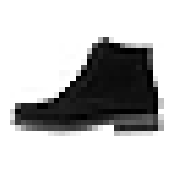

In [4]:
plt.figure(figsize = (2,2))
plt.imshow(X_train[42], cmap="binary")
plt.axis('off')
plt.show()

In [5]:
class_names = ["koszulka", "spodnie", "pulower", "sukienka", "kurtka",
"sandał", "koszula", "półbut", "torba", "but"]
class_names[y_train[42]]

'but'

In [6]:
model = tf.keras.models.Sequential()

In [7]:
model.add(tf.keras.layers.Flatten(input_shape=[28, 28]))
model.add(tf.keras.layers.Dense(300, activation="relu"))
model.add(tf.keras.layers.Dense(100, activation="relu"))
model.add(tf.keras.layers.Dense(10, activation="softmax"))

/Users/maciek/miniconda3/envs/ml/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
2025-05-09 17:43:17.530433: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2025-05-09 17:43:17.530459: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2025-05-09 17:43:17.530465: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.00 GB
I0000 00:00:1746805397.530480 6474487 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1746805397.530497 6474487 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableD

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="sgd",
              metrics=["accuracy"])

In [10]:
import os
root_logdir = os.path.join(os.curdir, "image_logs")

def get_run_logdir():
    import time
    run_id = time.strftime("run_%Y_%m_%d-%H_%M_%S")
    return os.path.join(root_logdir, run_id)
    
run_logdir = get_run_logdir()

In [11]:
tensorboard_cb = tf.keras.callbacks.TensorBoard(run_logdir)

In [12]:
history = model.fit(X_train, y_train, epochs=20,
                    validation_split=0.1, callbacks=tensorboard_cb)

Epoch 1/20
  15/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.1535 - loss: 2.3531    

2025-05-09 17:43:17.778386: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6711 - loss: 0.9886 - val_accuracy: 0.8058 - val_loss: 0.5378
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8196 - loss: 0.5287 - val_accuracy: 0.8235 - val_loss: 0.4902
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8354 - loss: 0.4778 - val_accuracy: 0.8385 - val_loss: 0.4667
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8422 - loss: 0.4557 - val_accuracy: 0.8372 - val_loss: 0.4602
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8440 - loss: 0.4514 - val_accuracy: 0.8435 - val_loss: 0.4450
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8477 - loss: 0.4396 - val_accuracy: 0.8388 - val_loss: 0.4422
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8472 - loss: 0.4405 - val_accuracy: 0.8398 - val_loss: 0.4559
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8467 - loss: 0.4383 - val_accurac

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Prediction: but
Confidence: 0.99974996
Truth: but


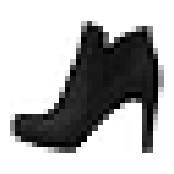

In [13]:
image_index = np.random.randint(len(X_test))
image = np.array([X_test[image_index]])
confidences = model.predict(image)
confidence = np.max(confidences[0])
prediction = np.argmax(confidences[0])
print("Prediction:", class_names[prediction])
print("Confidence:", confidence)
print("Truth:", class_names[y_test[image_index]])
plt.figure(figsize = (2,2))
plt.imshow(image[0], cmap="binary")
plt.axis('off')
plt.show()

In [14]:
model.save('fashion_clf.keras')

# Regresja

In [15]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

housing = fetch_california_housing()

In [16]:
X = housing.data
y = housing.target

In [17]:
X_train_temp, X_test, y_train_temp, y_test = train_test_split(X, y, test_size=0.1)

X_train, X_val, y_train, y_val = train_test_split(X_train_temp, y_train_temp, test_size=0.1)

In [18]:
model_h = tf.keras.models.Sequential()

In [19]:
normalizer = tf.keras.layers.Normalization()
normalizer.adapt(X_train)

In [20]:
model_h.add(normalizer)
model_h.add(tf.keras.layers.Dense(50, activation='relu', input_shape=[X_train.shape[1]]))
model_h.add(tf.keras.layers.Dense(50, activation='relu'))
model_h.add(tf.keras.layers.Dense(50, activation='relu'))
model_h.add(tf.keras.layers.Dense(1))

/Users/maciek/miniconda3/envs/ml/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
model_h.compile(loss="MeanSquaredError",
              optimizer="Adam",
              metrics=["RootMeanSquaredError"])

In [22]:
model_h.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (16718, 8)             │            17 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (72.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 17 (72.00 B)

In [23]:
es = tf.keras.callbacks.EarlyStopping(patience=5,
                                      min_delta=0.01,
                                      verbose=1)

In [24]:
root_logdir = os.path.join(os.curdir, "housing_logs")
run_logdir = get_run_logdir()
tensorboard_cb = tf.keras.callbacks.TensorBoard(run_logdir)

In [25]:
history_h = model_h.fit(X_train, y_train, epochs=200,
                        validation_data=(X_val, y_val), callbacks=[tensorboard_cb, es])

Epoch 1/200
523/523 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - RootMeanSquaredError: 1.4201 - loss: 2.0948 - val_RootMeanSquaredError: 0.7351 - val_loss: 0.5404
Epoch 2/200
523/523 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - RootMeanSquaredError: 0.9139 - loss: 0.8471 - val_RootMeanSquaredError: 0.8263 - val_loss: 0.6828
Epoch 3/200
523/523 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - RootMeanSquaredError: 2.0513 - loss: 4.5097 - val_RootMeanSquaredError: 2.2428 - val_loss: 5.0300
Epoch 4/200
523/523 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - RootMeanSquaredError: 5.6822 - loss: 36.6392 - val_RootMeanSquaredError: 2.0176 - val_loss: 4.0708
Epoch 5/200
523/523 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - RootMeanSquaredError: 1.3727 - loss: 2.3278 - val_RootMeanSquaredError: 1.0733 - val_loss: 1.1521
Epoch 6/200
523/523 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - RootMeanSquaredError: 1.5891 - loss: 2.7179 - val_RootMeanSquaredError: 1.1021 - val_loss: 1.2146
Epoch 6: early stopping


In [26]:
model_h.save('reg_housing_1.keras')

In [27]:
model_h_2 = tf.keras.models.Sequential()
model_h_2.add(tf.keras.layers.Dense(50, activation='relu', input_shape=[X_train.shape[1]]))
model_h_2.add(tf.keras.layers.Dense(50, activation='relu'))
model_h_2.add(tf.keras.layers.Dense(50, activation='relu'))
model_h_2.add(tf.keras.layers.Dense(1))
model_h_2.compile(loss="MeanSquaredError",
              optimizer="Adam",
              metrics=["RootMeanSquaredError"])
model_h_2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 50)             │           450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,601 (21.88 KB)

 Trainable params: 5,601 (21.88 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
root_logdir = os.path.join(os.curdir, "housing_logs")
run_logdir = get_run_logdir()
tensorboard_cb = tf.keras.callbacks.TensorBoard(run_logdir)
history_h_2 = model_h_2.fit(X_train, y_train, epochs=200,
                            validation_data=(X_val, y_val), callbacks=[tensorboard_cb, es])

Epoch 1/200
523/523 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - RootMeanSquaredError: 92.0854 - loss: 12881.0469 - val_RootMeanSquaredError: 1.9115 - val_loss: 3.6538
Epoch 2/200
523/523 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - RootMeanSquaredError: 2.5302 - loss: 6.5837 - val_RootMeanSquaredError: 1.5800 - val_loss: 2.4965
Epoch 3/200
523/523 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - RootMeanSquaredError: 2.6280 - loss: 7.1594 - val_RootMeanSquaredError: 1.3659 - val_loss: 1.8656
Epoch 4/200
523/523 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - RootMeanSquaredError: 2.1648 - loss: 5.3414 - val_RootMeanSquaredError: 4.1587 - val_loss: 17.2952
Epoch 5/200
523/523 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - RootMeanSquaredError: 8.8642 - loss: 83.5871 - val_RootMeanSquaredError: 2.3857 - val_loss: 5.6914
Epoch 6/200
523/523 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - RootMeanSquaredError: 6.9331 - loss: 56.0729 - val_RootMeanSquaredError: 2.1389 - val_loss: 4.5749
Epoch 7/200
523/523 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - RootMeanSquaredErro

In [29]:
model_h_2.save('reg_housing_2.keras')

In [30]:
model_h_3 = tf.keras.models.Sequential()
model_h_3.add(normalizer)
model_h_3.add(tf.keras.layers.Dense(200, activation='relu'))
model_h_3.add(tf.keras.layers.Dense(300, activation='relu'))
model_h_3.add(tf.keras.layers.Dense(100, activation='relu'))
model_h_3.add(tf.keras.layers.Dense(1))

model_h_3.compile(loss="MeanSquaredError",
                  optimizer="Adam",
                  metrics=["RootMeanSquaredError"])

model_h_3.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 8)              │            17 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (72.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 17 (72.00 B)

In [31]:
root_logdir = os.path.join(os.curdir, "housing_logs")
run_logdir = get_run_logdir()
tensorboard_cb = tf.keras.callbacks.TensorBoard(run_logdir)
history_h_3 = model_h_3.fit(X_train, y_train, epochs=200,
                            validation_data=(X_val, y_val), callbacks=[tensorboard_cb, es])

Epoch 1/200
523/523 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - RootMeanSquaredError: 1.6869 - loss: 3.5379 - val_RootMeanSquaredError: 1.2846 - val_loss: 1.6501
Epoch 2/200
523/523 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - RootMeanSquaredError: 2.7962 - loss: 8.4223 - val_RootMeanSquaredError: 1.6792 - val_loss: 2.8197
Epoch 3/200
523/523 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - RootMeanSquaredError: 5.8540 - loss: 41.5787 - val_RootMeanSquaredError: 2.6550 - val_loss: 7.0490
Epoch 4/200
523/523 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - RootMeanSquaredError: 7.2686 - loss: 55.8419 - val_RootMeanSquaredError: 8.0065 - val_loss: 64.1043
Epoch 5/200
523/523 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - RootMeanSquaredError: 6.4418 - loss: 44.3050 - val_RootMeanSquaredError: 0.7617 - val_loss: 0.5802
Epoch 6/200
523/523 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - RootMeanSquaredError: 2.4240 - loss: 7.2143 - val_RootMeanSquaredError: 5.0355 - val_loss: 25.3561
Epoch 7/200
523/523 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - RootMeanSquaredError: 

In [32]:
model_h_3.save('reg_housing_3.keras')